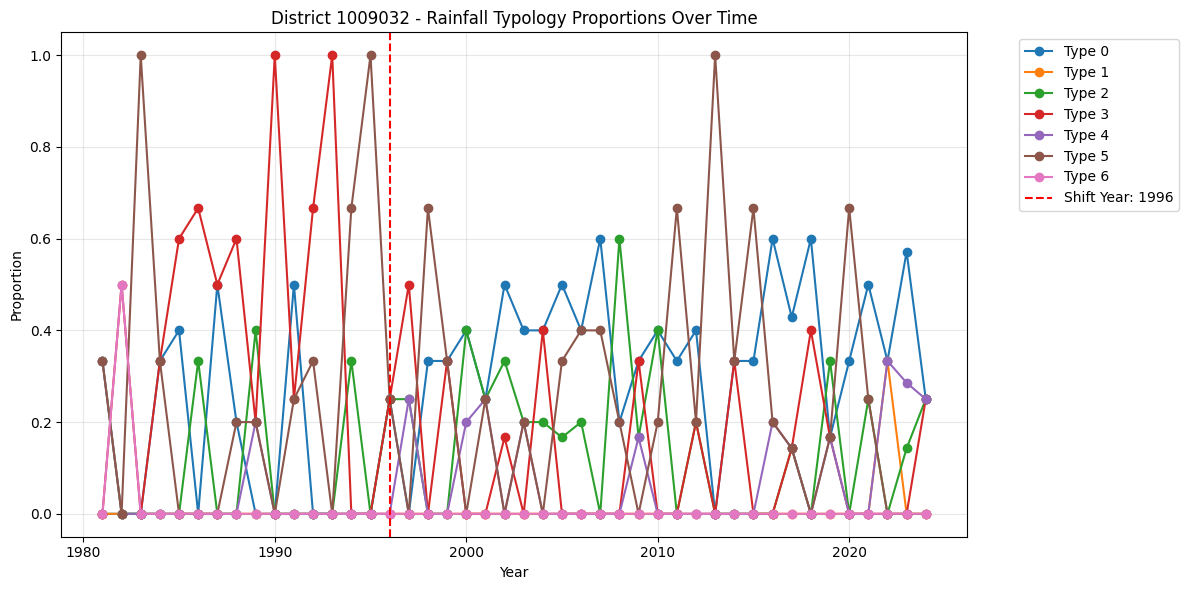

In [14]:
import pandas as pd
import numpy as np
from ruptures import Pelt
import matplotlib.pyplot as plt

clustered_events = pd.read_csv('clustered_rainfall_events.csv')

if 'event_year' not in clustered_events.columns:
    original_df = pd.read_csv('Data/pakistan_rain.csv', skiprows=[1])
    original_df['date'] = pd.to_datetime(original_df['date'])
    original_df = original_df.sort_values(['adm2_id', 'date'])
    
    year_map = {}
    for district in original_df['adm2_id'].unique():
        dist_df = original_df[original_df['adm2_id'] == district].copy()
        dist_df['is_wet'] = dist_df['rfh'] > 5
        dist_df['event_start'] = dist_df['is_wet'] & ~dist_df['is_wet'].shift(1, fill_value=False)
        dist_df['event_index'] = dist_df['event_start'].cumsum() - 1

        grouped = dist_df[dist_df['is_wet']].groupby('event_index')
        for e_idx, group in grouped:
            rep_year = int(group['date'].dt.year.mode()[0])
            year_map[(district, int(e_idx))] = rep_year

    clustered_events['year'] = clustered_events.apply(
        lambda row: year_map.get((row['district_id'], row['event_index']), 2000), axis=1
    )
else:
    clustered_events['year'] = clustered_events['event_year']

clustered_events = clustered_events.sort_values(['district_id', 'event_index'])
clustered_events['district'] = clustered_events['district_id']
clustered_events['typology'] = clustered_events['rainfall_type_name'].astype(str)

def calculate_yearly_proportions(events_df):
    grouped = events_df.groupby(['district', 'year', 'typology']).size().unstack(fill_value=0)
    proportions = grouped.div(grouped.sum(axis=1), axis=0).reset_index()
    proportions = proportions.fillna(0)
    return proportions

def detect_regime_shifts(proportions_df, pen=5, min_years=8):
    shifts = []
    typology_cols = [col for col in proportions_df.columns if col not in ['district', 'year']]
    
    for district in sorted(proportions_df['district'].unique()):
        df_d = proportions_df[proportions_df['district'] == district].sort_values('year')

        if len(df_d) < min_years:
            continue

        signal_col = 'Type 0' if 'Type 0' in typology_cols else typology_cols[0]
        signal = df_d[signal_col].values

        try:
            model = Pelt(model="rbf").fit(signal)
            cps = model.predict(pen=pen)

            if len(cps) > 1:
                cp_idx = cps[0]
                shift_year = int(df_d['year'].iloc[cp_idx])

                pre_shift = df_d[df_d['year'] < shift_year]
                post_shift = df_d[df_d['year'] >= shift_year]
                
                pre_props = pre_shift[typology_cols].mean().to_dict()
                post_props = post_shift[typology_cols].mean().to_dict()

                shifts.append({
                    'district': district,
                    'shift_year': shift_year,
                    'total_years': len(df_d),
                    'confidence': 'high',
                    'pre_shift_props': pre_props,
                    'post_shift_props': post_props
                })
        except:
            pass
    
    shift_df = pd.DataFrame(shifts)
    return shift_df

def analyze_regime_shifts(shift_df, proportions_df):
    if shift_df.empty:
        return pd.DataFrame()
    
    analysis_results = []
    typology_cols = [col for col in proportions_df.columns if col not in ['district', 'year']]
    
    for _, shift in shift_df.iterrows():
        district = shift['district']
        shift_year = shift['shift_year']
        
        district_data = proportions_df[proportions_df['district'] == district].sort_values('year')
        
        pre_data = district_data[district_data['year'] < shift_year]
        post_data = district_data[district_data['year'] >= shift_year]
        
        pre_composition = pre_data[typology_cols].mean()
        post_composition = post_data[typology_cols].mean()
        
        shift_magnitude = (abs(pre_composition - post_composition)).sum() / 2
        changes = abs(pre_composition - post_composition)
        most_changed = changes.idxmax()
        most_changed_value = changes.max()
        
        analysis_results.append({
            'district': district,
            'shift_year': shift_year,
            'shift_magnitude': shift_magnitude,
            'most_changed_typology': most_changed,
            'most_changed_magnitude': most_changed_value,
            'pre_' + most_changed: pre_composition[most_changed],
            'post_' + most_changed: post_composition[most_changed]
        })
    
    return pd.DataFrame(analysis_results)

yearly_props_df = calculate_yearly_proportions(clustered_events)
shift_df = detect_regime_shifts(yearly_props_df, pen=5)

if not shift_df.empty:
    analysis_df = analyze_regime_shifts(shift_df, yearly_props_df)
else:
    analysis_df = pd.DataFrame()

shift_df.to_csv('detected_regime_shifts.csv', index=False)
yearly_props_df.to_csv('yearly_typology_proportions.csv', index=False)

if not shift_df.empty:
    sample_districts = shift_df['district'].head(3).tolist()
    for district in sample_districts:
        district_data = yearly_props_df[yearly_props_df['district'] == district].sort_values('year')
        shift_year = shift_df[shift_df['district'] == district]['shift_year'].iloc[0]
        
        typology_cols = [col for col in district_data.columns if col not in ['district', 'year']]
        
        plt.figure(figsize=(12, 6))
        for col in typology_cols:
            plt.plot(district_data['year'], district_data[col], label=col, marker='o')
        plt.axvline(x=shift_year, color='red', linestyle='--', label=f'Shift Year: {shift_year}')
        plt.xlabel('Year')
        plt.ylabel('Proportion')
        plt.title(f'District {district} - Rainfall Typology Proportions Over Time')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()